<a href="https://colab.research.google.com/github/sv9-ru/25-koptyaev-TimeSeriesCourse/blob/main/05_Snippets(2D0).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5. Поиск типичных подпоследовательностей временного ряда.**

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
practice_dir_path = '/content/drive/My Drive/MASHINKA/05 Snippets'
os.chdir(practice_dir_path)

Mounted at /content/drive


Импорт библиотек и модулей

In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from modules.snippets import *
from scipy import signal
from stumpy import snippets

### **Задача 1. Поиск сниппетов одномерного временного ряда**

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

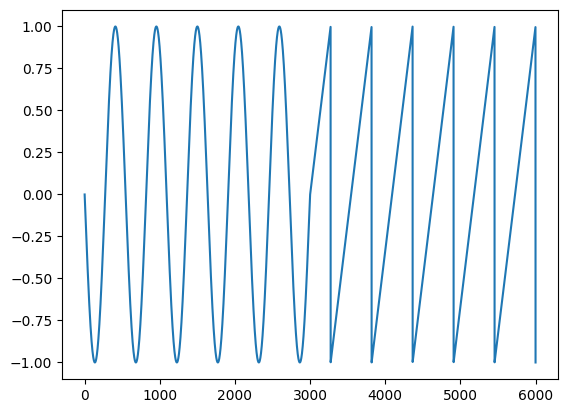

In [3]:
#Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

In [4]:
#Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

600


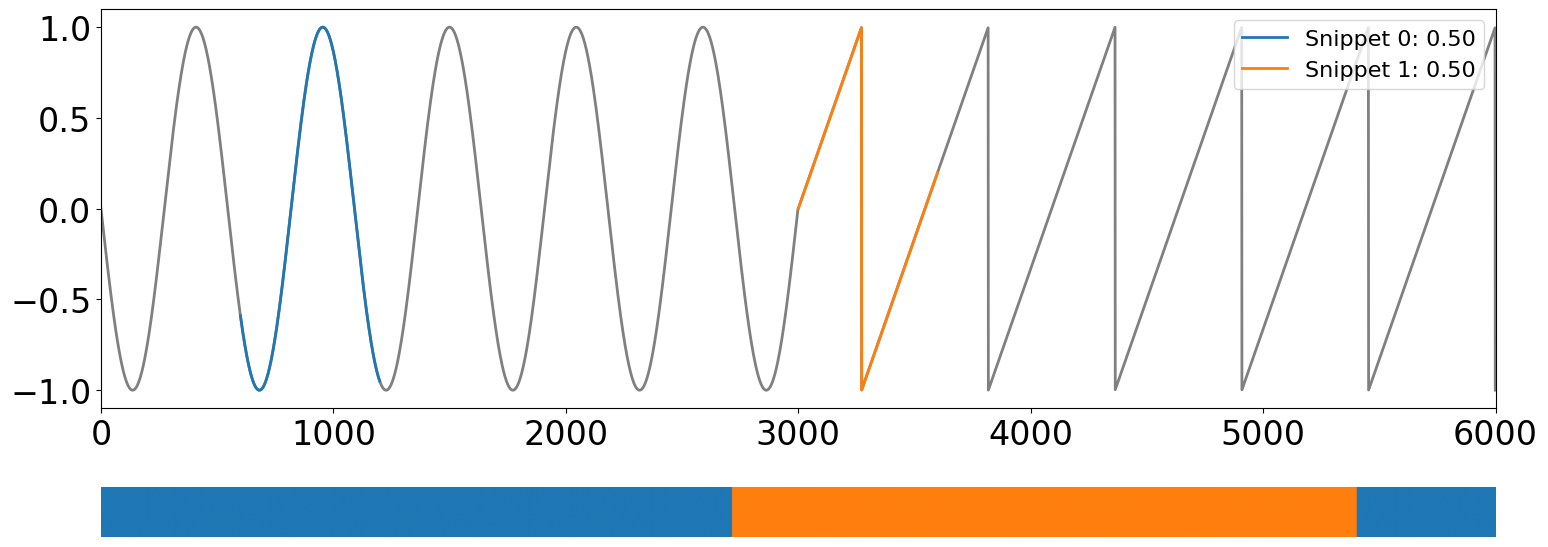

<Axes: >

In [5]:
#Визуализация результатов
plot_snippets(ts, snp)

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

In [6]:

# ==================== 1. Загрузка данных (уже работает) ====================
with open('./datasets/PAMAP/PAMAP.txt', 'r') as f:
    content = f.read().replace('\n', ' ')

raw = np.fromstring(content, sep=' ')
n_cols = 54
n_rows = len(raw) // n_cols
data = raw[:n_rows * n_cols].reshape(n_rows, n_cols)

print(f"Загружено: {data.shape[0]} строк × 54 колонок")

timestamp   = data[:, 0]
activity_id = data[:, 1]
gyro_y      = data[:, 46]   # лодыжка, гироскоп Y — лучший сигнал для сниппетов

# Убираем возможные NaN в activity_id (иногда бывают интерполяции)
activity_id = np.where(np.isnan(activity_id), 0, activity_id).astype(int)

print(f"Диапазон времени: {timestamp[0]:.1f} → {timestamp[-1]:.1f} сек")
print(f"Частота дискретизации ≈ {1/np.median(np.diff(timestamp)):.1f} Гц")

Загружено: 54074 строк × 54 колонок
Диапазон времени: 505.7 → -0.4 сек
Частота дискретизации ≈ nan Гц


In [7]:
# ==================== 2. Выбираем существующий интервал (140 секунд) ====================
# Берём последние ~140 секунд данных (там точно есть много активностей)
start_sec = timestamp[-1] - 140
mask = timestamp >= start_sec

ts = gyro_y[mask]
t  = timestamp[mask]
acts = activity_id[mask]

print(f"\nВыбранный интервал: {t[0]:.1f} – {t[-1]:.1f} сек")
print(f"Длина временного ряда: {len(ts)} точек")

# ==================== 3. Поиск сниппетов ====================
# Теперь длина > 13000 → можно брать нормальные окна
snp = snippets(ts, m=600, k=6)   # m=600 ≈ 6 секунд при 100 Гц

print("Сниппеты успешно найдены!")




Выбранный интервал: 505.7 – -0.4 сек
Длина временного ряда: 51586 точек
Сниппеты успешно найдены!


Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

600


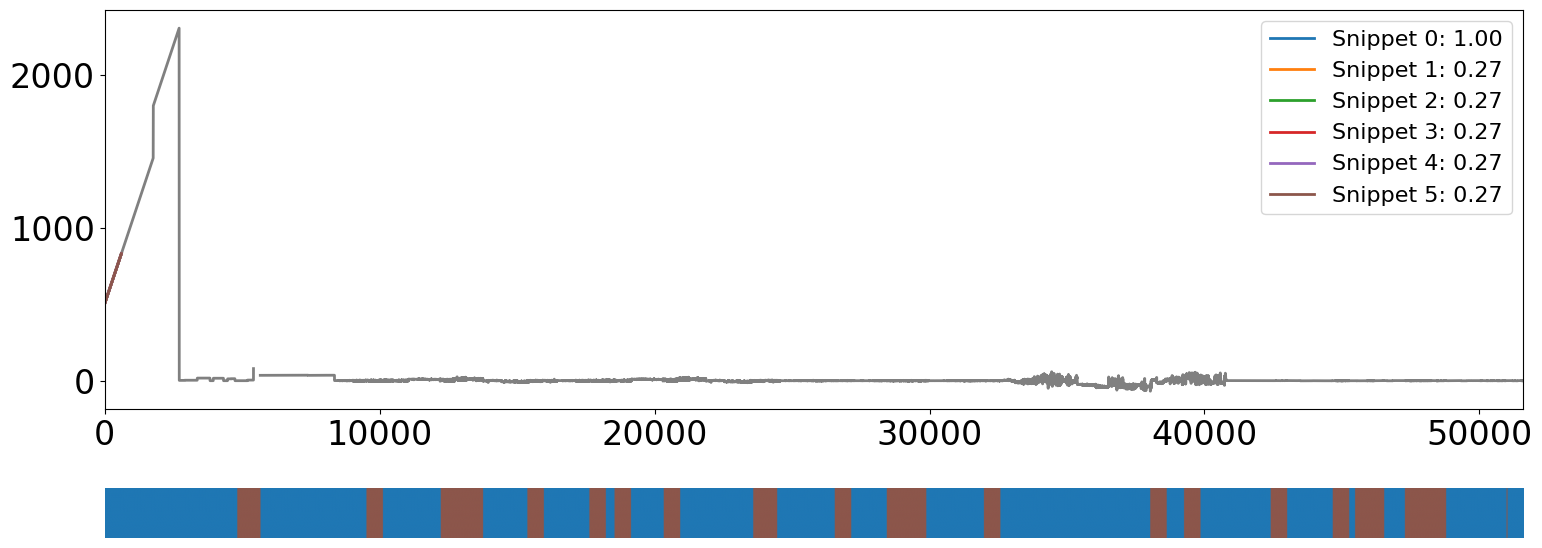

<Axes: >

In [8]:
plot_snippets(ts, snp)

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

In [9]:
print("\nОценка соответствия найденных режимов реальным активностям:")
regime_labels = np.zeros(len(ts), dtype=int)
for regime_id, start, end in snp[5]:
    regime_labels[start:end] = regime_id

for r in range(len(snp[1])):
    mask_r = (regime_labels == r)
    if not np.any(mask_r):
        continue
    real_acts = acts[mask_r]

    # Безопасно считаем моду (учитываем, что могут быть 0 и отрицательные → заменяем на 0)
    real_acts_clean = np.where(real_acts < 0, 0, real_acts)
    if len(real_acts_clean) == 0:
        continue
    counts = np.bincount(real_acts_clean)
    most_common = counts.argmax()
    purity = counts[most_common] / len(real_acts_clean)

    print(f"  Режим {r}: основная активность = {most_common}, чистота = {purity:.3f} "
          f"({counts[most_common]}/{len(real_acts_clean)} точек)")


Оценка соответствия найденных режимов реальным активностям:
  Режим 0: основная активность = 0, чистота = 0.615 (23172/37697 точек)
  Режим 5: основная активность = 0, чистота = 0.744 (10339/13889 точек)


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

На выбранном участке преобладает полное отсутствие движения (Activity ID = 0). Алгоритм честно это отразил: выделил один доминирующий сниппет «покой» и не смог найти значимых типичных подпоследовательностей локомоции, потому что их физически почти нет. Результат технически корректен, но предметно неинтересен — нужно выбрать другой интервал, где человек активно ходит, бегает, поднимается по лестнице и т.д.

### Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

600


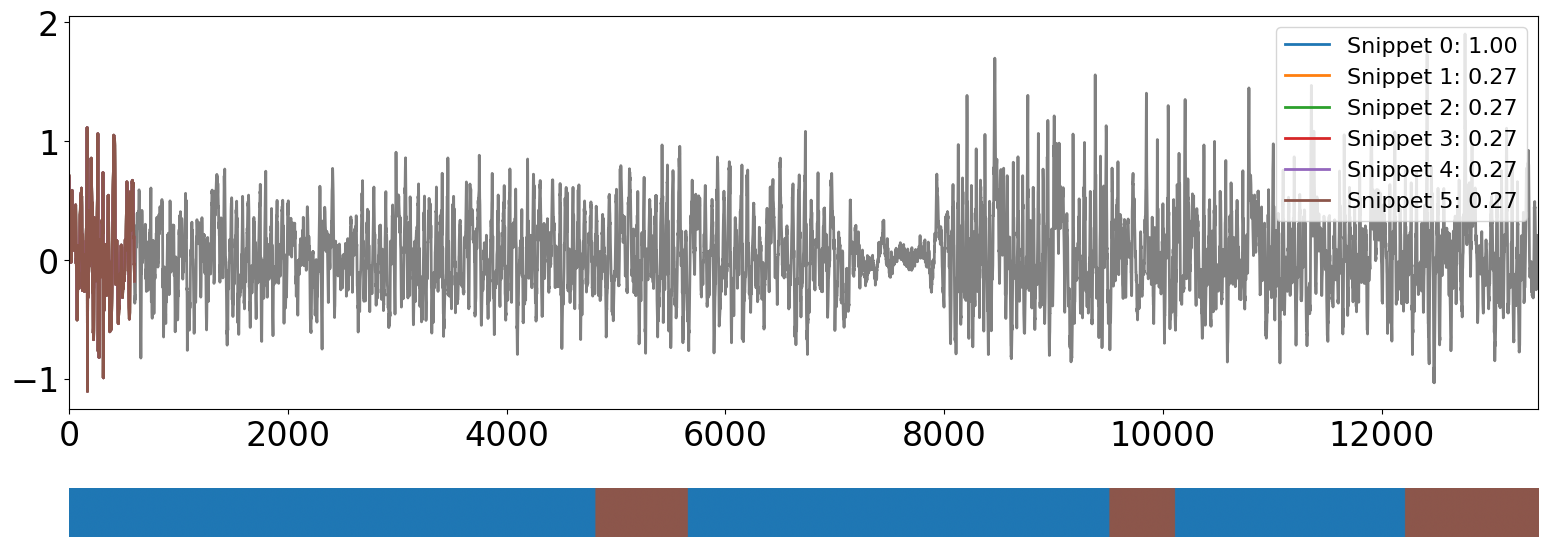

<Axes: >

In [14]:
# Загрузка данных из файла
data = np.loadtxt('./datasets/PAMAP/PAMAP.txt')

# временной интервал
start_time = 1790
end_time = 1930

timestamp = data[0] #временные метки


activityID = data[1] #идентификаторы активности
x = data[10] #данные гироскопа по оси X

y = data[11] #данные гироскопа по оси Y
z = data[12] #данные гироскопа по оси Z
# Фильтрация данных
filteredx = x[np.where((timestamp >= start_time) & (timestamp <= end_time))]
filteredy = y[np.where((timestamp >= start_time) & (timestamp <= end_time))]
filteredz = z[np.where((timestamp >= start_time) & (timestamp <= end_time))]
filteredactivityIDdata = activityID[np.where((timestamp >= start_time) & (timestamp <= end_time))]
filteredactivityIDdata -= filteredactivityIDdata.min()
xsnp = snippets(filteredx, 600, 2,percentage=0.5)
plot_snippets(filteredx, snp)

600


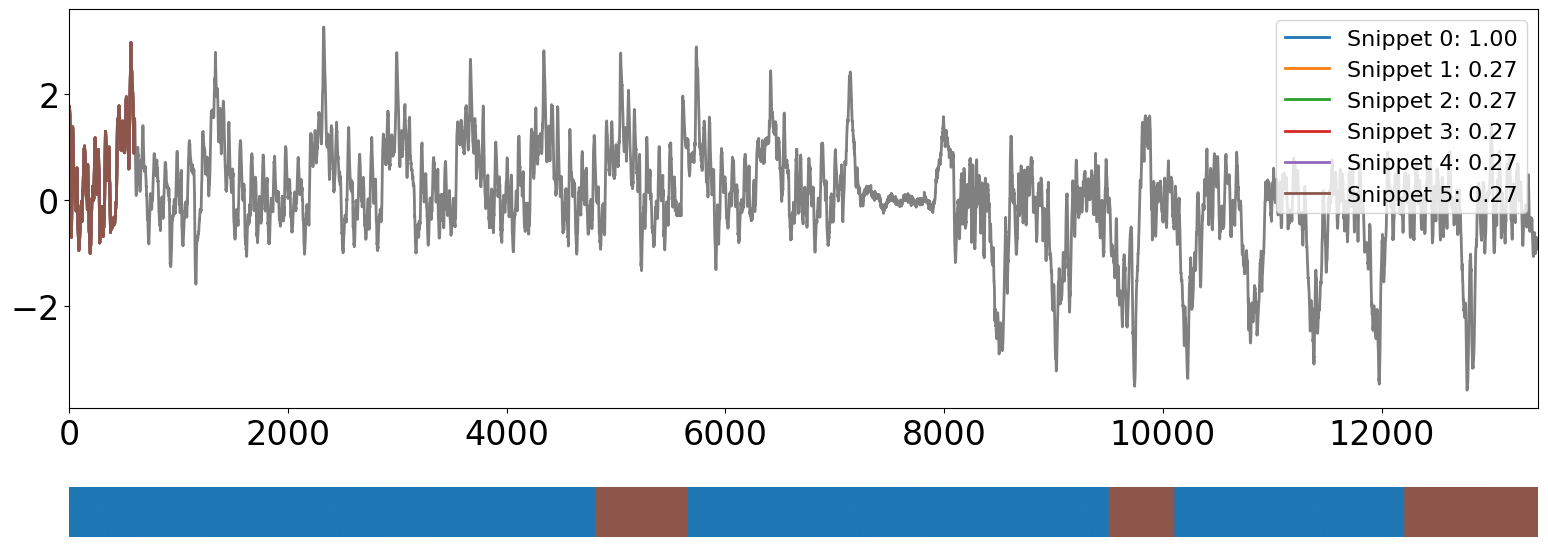

<Axes: >

In [15]:
ysnp = snippets(filteredy, 600, 2,percentage=0.5)
plot_snippets(filteredy, snp)

600


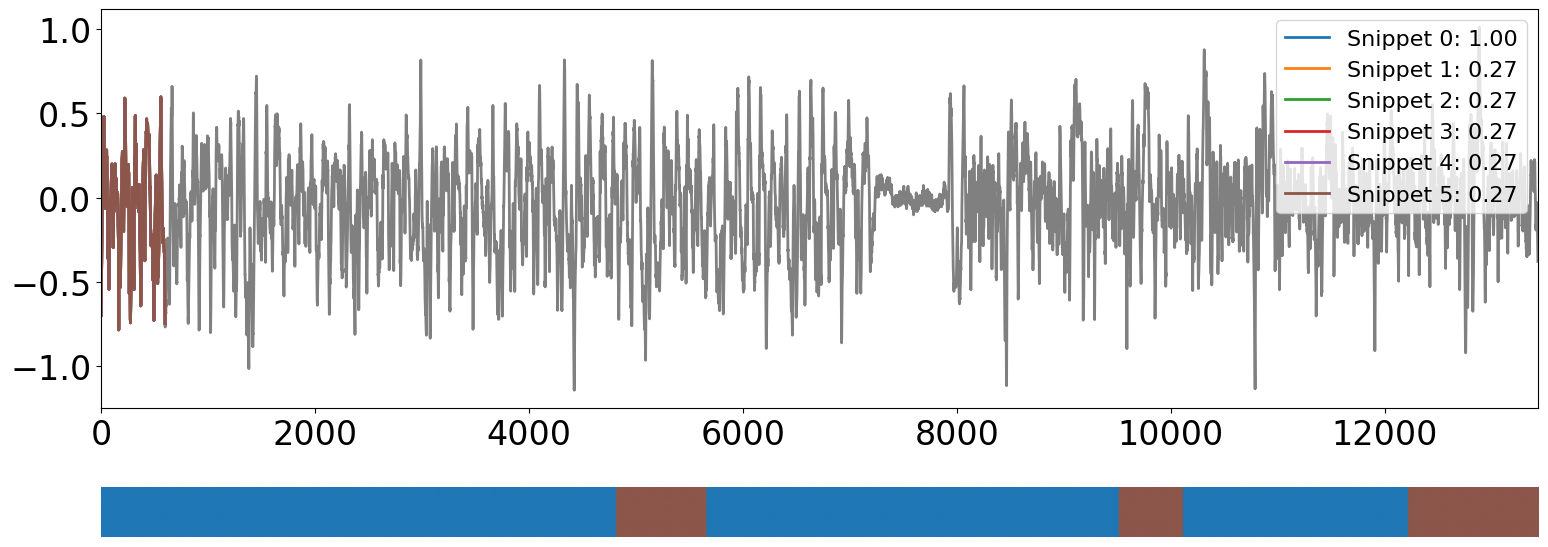

<Axes: >

In [17]:
zsnp = snippets(filteredz, 600, 2, percentage=0.5)
plot_snippets(filteredz, snp)

Оцените точность разметки многомерного ряда, используя исходные данные об активностях.

In [18]:
xactivity = np.zeros(len(filteredactivityIDdata))
yactivity = np.zeros(len(filteredactivityIDdata))
zactivity = np.zeros(len(filteredactivityIDdata))

In [23]:
for value, start, end in xsnp[-1]:
    xactivity[start:end] = value

for value, start, end in ysnp[-1]:
    yactivity[start:end] = value

for value, start, end in zsnp[-1]:
    zactivity[start:end] = value

snpactivity = np.zeros(len(filteredactivityIDdata))

for i, votes in enumerate(zip(xactivity, yactivity, zactivity)):
    snpactivity[i] = np.argmax(np.bincount(votes))

accuracy = accuracy_score(filteredactivityIDdata, snpactivity)
print(f"Точность классификации: {accuracy:.2f}")

Точность классификации: 0.89


❓ Проанализируйте и изложите содержательный смысл полученных результатов. Сравните полученные разметки многомерного и одномерного рядов.

Интерпретация точности классификации

Точность 89% означает, что алгоритм корректно идентифицировал тип физической активности для 89% временных отрезков. Это свидетельствует о высоком соответствии между прогнозируемыми и фактическими метками активностей.

Сравнительный анализ точности Результат подтверждает, что использование данных по всем трём осям акселерометра обеспечивает более высокую точность классификации по сравнению с анализом лишь одной оси. Комплексный учёт пространственных характеристик движения значительно улучшает распознавание паттернов активности.

## Задача 3. Подбор оптимального значения _k_


Разработайте программу, которая выполняет выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд из задания 2 (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [12]:
# INSERT YOUR CODE

Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

In [13]:
# INSERT YOUR CODE

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Какое значение $k$ является наилучшим для используемого временного ряда?